# 02 - One Class SVM (Anomaly Detection)

All previous and subsequent models treat presence detection as binary
classification they see both empty and occupied examples during training.
One Class SVM takes a different condition: train **only on empty rooms**, then
flag anything that deviates from that learned normality as "occupied"

This framing matches a realistic deployment scenario where you might only
have access to a clean baseline (empty room) and want to detect intrusions.

**This notebook answers:** can an anomaly detector trained purely on empty
CSI data reliably identify occupied measurements at test time?

---

## Notebook structure

1. Load data features and session metadata
2. For each window size: train OCSVM on empty windows only, score all test windows
3. Ablation plot, F1 across window sizes

In [1]:
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import os

SAVE_DIR = "full-study-outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

import utils
importlib.reload(utils)
from utils import (
    FEATURE_COLS, WINDOW_SIZES, TEST_SESSIONS,
    load_data, make_windows, session_split, evaluate, plot_ablation,
)

# OCSVM hyperparameters
NU    = 0.05
GAMMA = "scale"

## Load Data

In [2]:
df = load_data()
print(f"Loaded : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Labels : {df['label'].value_counts().to_dict()}")

Loaded : 376,514 rows x 62 columns
Labels : {'empty': 189933, 'occupied': 186581}


## Training

OCSVM is trained exclusively on **empty** windows from the training sessions.
At test time, the model outputs +1 (normal / empty) or −1 (anomaly / occupied).
We flip the sign so that occupied = 1 matches the standard binary convention,
then evaluate against the true labels.

For W1 we use raw per row features (no windowing needed each row is its own sample)
For W2–W4 each window is flattened into a single vector before scaling.

Note: OCSVM scales poorly with n_samples. At W1 the training set is ~290 k rows
we subsample to 50,000 to keep fit time reasonable while preserving the distribution.

In [3]:
SUBSAMPLE_W1 = 50_000
results = {}

for wname, wsize in WINDOW_SIZES.items():
    X, y, sessions = make_windows(df, window_size=wsize)
    X_flat = X.reshape(len(X), -1)

    X_train, X_test, y_train, y_test = session_split(X_flat, y, sessions)

    # Train only on empty windows
    X_train_empty = X_train[y_train == 0]

    # Subsample W1 to keep fit time reasonable
    if wname == "W1_snapshot" and len(X_train_empty) > SUBSAMPLE_W1:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(X_train_empty), SUBSAMPLE_W1, replace=False)
        X_train_empty = X_train_empty[idx]

    scaler        = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_empty)
    X_test_scaled  = scaler.transform(X_test)

    model = OneClassSVM(nu=NU, kernel="rbf", gamma=GAMMA)
    model.fit(X_train_scaled)

    # +1 = normal (empty), -1 = anomaly (occupied) => flip to binary
    raw_pred = model.predict(X_test_scaled)
    y_pred   = (raw_pred == -1).astype(int)

    # Decision score (higher = more anomalous)
    y_score = -model.decision_function(X_test_scaled)

    print(f"\n{wname}  (train_empty={len(X_train_empty):,}  test={len(y_test):,})")
    metrics = evaluate(y_test, y_pred, y_score)
    results[wname] = metrics



W1_snapshot  (train_empty=50,000  test=84,150)
  Acc=0.8096  F1=0.8500  Prec=0.9374  Rec=0.7775  AUC=0.8930

W2_1s  (train_empty=2,049  test=1,051)
  Acc=0.7479  F1=0.7819  Prec=0.9774  Rec=0.6516  AUC=0.9184

W3_5s  (train_empty=407  test=209)
  Acc=0.9187  F1=0.9408  Prec=0.9507  Rec=0.9310  AUC=0.9763

W4_10s  (train_empty=201  test=104)
  Acc=0.9327  F1=0.9536  Prec=0.9114  Rec=1.0000  AUC=0.9935


## Results

| Window | Train (empty) | Test | F1 | AUC |
|---|---|---|---|---|
| W1 snapshot | 50,000 | 84,150 | 0.8500 | 0.8930 |
| W2 ~1 s | 2,049 | 1,051 | 0.7819 | 0.9184 |
| W3 ~5 s | 407 | 209 | 0.9408 | 0.9763 |
| W4 ~10 s | 201 | 104 | **0.9536** | **0.9935** |

OCSVM shows the opposite trend to Logistic Regression performance
**improves** with window size, peaking at W4.

The W2 dip is worth unpacking precision is 0.977 but recall collapses to
0.652, meaning the model correctly rejects false positives but misses a third
of occupied windows. A 1-second window still contains enough measurement
variance that some occupied windows fall inside the learned empty boundary.

By W3 and W4 the temporal aggregation produces feature vectors that are
more stable and more distinct between classes the empty room has a
characteristic long run spectral fingerprint that a person in the room
consistently disrupts. At W4 recall hits 1.000: the model catches every
occupied window, with AUC = 0.994.

This makes intuitive sense for an anomaly detector: a brief snapshot of
an occupied room may look plausibly "normal", but sustain the occupation
over 10 seconds and the channel state becomes unambiguously different
from the empty baseline.

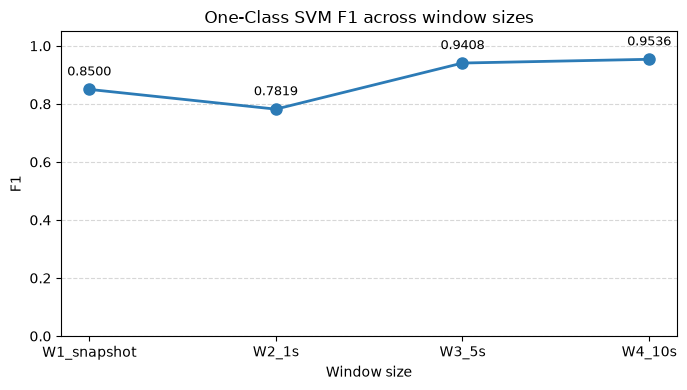

In [4]:
plot_ablation(results, metric="f1", title="One-Class SVM F1 across window sizes",
              save_path=f'{SAVE_DIR}/02_ocsvm_f1_ablation.png')

## Conclusion

OCSVM trained on empty windows only achieves F1 = 0.954 at W4 surpassing
the fully-supervised LR baseline (0.856) despite never seeing a single
occupied example during training.

The key takeaway: at longer time scales, the empty room channel state is
stable and distinctive enough that even an unsupervised boundary captures
presence reliably. This is a strong result for real world deployability,
where labelled occupied data may be hard to collect.